In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv("titanic_toy.csv")


In [4]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [5]:
df.shape

(891, 4)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [7]:
df.isnull().sum()

Age         177
Fare         45
Family        0
Survived      0
dtype: int64

In [8]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [9]:
X = df.drop(columns =['Survived'])
y=df['Survived']

In [10]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [11]:
X_train

,Age,Fare,Family
140,NaN,15.2458,2
439,31.0,10.5000,0
817,31.0,37.0042,2
378,20.0,NaN,0
491,21.0,7.2500,0
...,...,...,...
835,39.0,83.1583,2
192,19.0,7.8542,1
629,NaN,7.7333,0
559,36.0,17.4000,1


In [12]:
X_test

,Age,Fare,Family
495,NaN,14.4583,0
648,NaN,7.5500,0
278,7.0,29.1250,5
31,NaN,146.5208,1
255,29.0,15.2458,2
...,...,...,...
780,13.0,7.2292,0
837,NaN,8.0500,0
215,31.0,113.2750,1
833,23.0,7.8542,0


In [13]:
y_train

140    0
439    0
817    0
378    0
491    0
      ..
835    1
192    1
629    0
559    1
684    0
Name: Survived, Length: 712, dtype: int64

In [14]:
X_train.isnull().mean()*100

Age       19.803371
Fare       5.477528
Family     0.000000
dtype: float64

In [31]:
X_train.describe()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
count,571.000000,673.000000,712.000000,712.000000,712.000000,712.000000,712.000000
mean,29.745184,31.885314,0.921348,29.745184,29.597612,31.885314,30.930520
std,14.619046,50.738079,1.664385,13.089458,13.092831,49.326903,49.486332
min,0.670000,0.000000,0.000000,0.670000,0.670000,0.000000,0.000000
25%,20.750000,7.925000,0.000000,22.000000,22.000000,7.925000,7.925000
50%,29.000000,14.454200,0.000000,29.745184,29.000000,15.500000,14.454200
75%,38.000000,31.275000,1.000000,35.000000,35.000000,31.885314,30.178100
max,80.000000,512.329200,10.000000,80.000000,80.000000,512.329200,512.329200


In [ ]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

In [16]:
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)
X_train['Age_median'] = X_train['Age'].fillna(median_age)

X_train['Fare_mean'] =X_train['Fare'].fillna(mean_fare)
X_train['Fare_median'] = X_train['Fare'].fillna(median_fare)


In [17]:
X_train.sample(5)

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
95,NaN,8.0500,0,29.745184,29.0,8.0500,8.0500
746,16.0,20.2500,2,16.000000,16.0,20.2500,20.2500
869,4.0,11.1333,2,4.000000,4.0,11.1333,11.1333
15,55.0,16.0000,0,55.000000,55.0,16.0000,16.0000
431,NaN,16.1000,1,29.745184,29.0,16.1000,16.1000


In [20]:
#Comparing variance of age , age mean  and age median
print(X_train['Age'].var())
print(X_train['Age_mean'].var())
print(X_train['Age_median'].var())

213.7165085187578
171.33390978297038
171.42222438960798


In [21]:
#Comparing variance of Fare , Fare mean  and Fare median
print(X_train['Fare'].var())
print(X_train['Fare_mean'].var())
print(X_train['Fare_median'].var())

2574.3526206637193
2433.143405184275
2448.897024777755


#### plotting kde plot to check changes between mean, median and original columns

<Axes: ylabel='Density'>

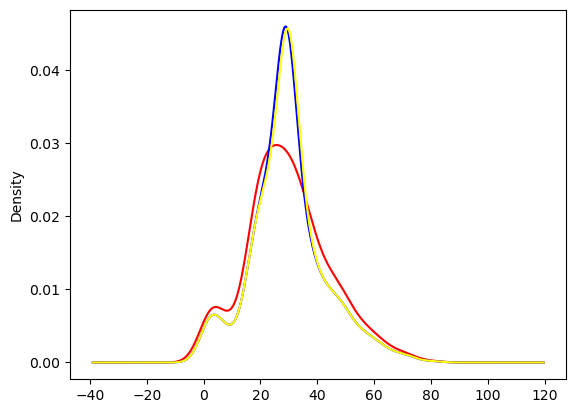

In [ ]:
#kernel density estimate shows probability density if there is a peak in a area it means the most values are residing there
fig = plt.figure()
ax = fig.add_subplot(111)

X_train['Age'].plot(kind='kde',ax =ax , color = 'red')

X_train['Age_median'].plot(kind = 'kde' , ax = ax , color = 'blue')

X_train['Age_mean'].plot(kind = 'kde' , ax = ax ,color = 'yellow')


<Axes: ylabel='Density'>

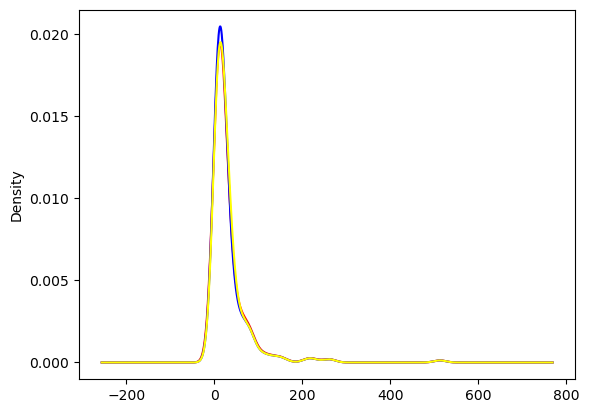

In [24]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train['Fare'].plot(kind='kde',ax =ax , color = 'red')

X_train['Fare_median'].plot(kind = 'kde' , ax = ax , color = 'blue')

X_train['Fare_mean'].plot(kind = 'kde' , ax = ax ,color = 'yellow')


##### Checking covariance of mean , median columns with other columns to check changes 


In [26]:
#Covariance measures the direction of the linear relationship between two numerical variables.
X_train.cov()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,213.716509,84.480223,-6.393469,213.716509,213.716509,79.571049,79.420930
Fare,84.480223,2574.352621,17.050423,67.493301,68.754981,2574.352621,2574.352621
Family,-6.393469,17.050423,2.770177,-5.125566,-5.121468,16.115167,16.285129
Age_mean,213.716509,67.493301,-5.125566,171.333910,171.333910,63.791137,63.670788
Age_median,213.716509,68.754981,-5.121468,171.333910,171.422224,64.983611,64.831778
Fare_mean,79.571049,2574.352621,16.115167,63.791137,64.983611,2433.143405,2433.143405
Fare_median,79.420930,2574.352621,16.285129,63.670788,64.831778,2433.143405,2448.897025


In [ ]:
#It tells you how strongly two variables move together on a standardized scale — unlike covariance, which is scale-dependent.
X_train.corr()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,1.000000,0.106334,-0.295318,1.000000,1.000000,0.103929,0.103346
Fare,0.106334,1.000000,0.198661,0.101058,0.102921,1.000000,1.000000
Family,-0.295318,0.198661,1.000000,-0.235270,-0.235021,0.196290,0.197721
Age_mean,1.000000,0.101058,-0.235270,1.000000,0.999742,0.098800,0.098295
Age_median,1.000000,0.102921,-0.235021,0.999742,1.000000,0.100620,0.100062
Fare_mean,0.103929,1.000000,0.196290,0.098800,0.100620,1.000000,0.996778
Fare_median,0.103346,1.000000,0.197721,0.098295,0.100062,0.996778,1.000000


#### checking outliers

<Axes: >

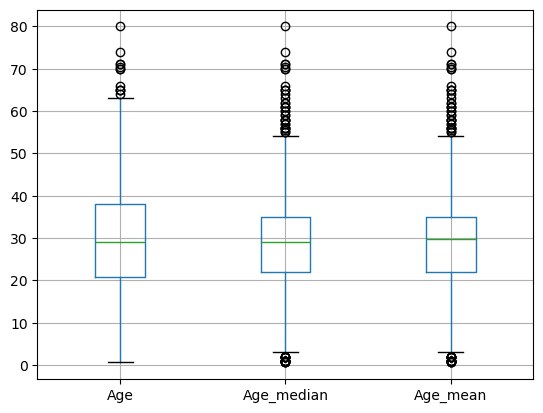

In [29]:
X_train[['Age' , 'Age_median' ,'Age_mean']].boxplot()

<Axes: >

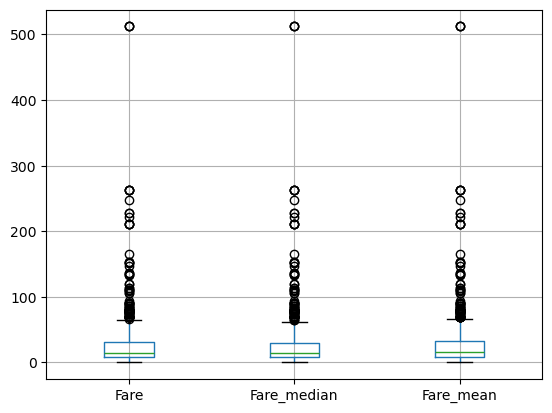

In [32]:
X_train[['Fare' , 'Fare_median' ,'Fare_mean']].boxplot()

#### conclusion - I can use mean or median imputation for fare but for age i can't use mean/median imputation

## Learning to implement by scikit learn

In [33]:
X_train , X_test , y_train , y_test = train_test_split(X ,y , test_size=0.2 , random_state=2)

In [34]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [35]:
trf = ColumnTransformer([
    ('imputer1' , imputer1 , ['Age']),
    ('imputer2',imputer2 ,['Fare'])
],remainder='passthrough')

In [36]:
trf.fit(X_train)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['Age']),
                                ('imputer2', SimpleImputer(), ['Fare'])])

In [37]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [38]:
trf.named_transformers_['imputer2'].statistics_

array([32.61759689])

In [39]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [40]:
X_train


array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]])